In [2]:
import re

def parse_benchmark_file(file_path):
    """
    Parse the benchmark file and extract the number of particles and the timer per evaluation for each block.

    Parameters:
        file_path (str): The path to the benchmark file.

    Returns:
        tuple: Two lists:
            - n_particles: A list of integers representing the number of atoms for each block.
            - timer_per_eval: A list of floats representing the timer per evaluation in each block.
    """
    n_particles = []
    timer_per_eval = []

    with open(file_path, 'r') as f:
        content = f.read()

    # Split the file into blocks using a line of equals signs as the delimiter.
    blocks = re.split(r"={10,}", content)
    
    for block in blocks:
        block = block.strip()
        if not block:
            continue  # Skip empty blocks
        
        # Use a regex to extract the number of atoms from the line like:
        # "benchmarking 10000 energy evaluations for 10 atoms"
        np_match = re.search(r"for\s+(\d+)\s+atoms", block)
        if np_match:
            n = int(np_match.group(1))
        else:
            continue
        
        # Use a regex to extract the timer per evaluation value from the line like:
        # "timer per evaluation: 2.6606e-06"
        time_match = re.search(r"timer per evaluation:\s*([\deE\.\-]+)", block)
        if time_match:
            t = float(time_match.group(1))
        else:
            continue
        
        n_particles.append(n)
        timer_per_eval.append(t)
    
    return n_particles, timer_per_eval

In [3]:
old_inversepower_bench = parse_benchmark_file("/home/praharsh/research/bv-libraries-old/pele/cpp_tests/source/benchmarks/bench_inversepower.out")
inversepower_bench = parse_benchmark_file("/home/praharsh/research/bv-libraries/pele/cpp_tests/source/benchmarks/bench_inversepower.out")
old_lj_bench = parse_benchmark_file("/home/praharsh/research/bv-libraries-old/pele/cpp_tests/source/benchmarks/bench_lj.out")
lj_bench = parse_benchmark_file("/home/praharsh/research/bv-libraries/pele/cpp_tests/source/benchmarks/bench_lj.out")

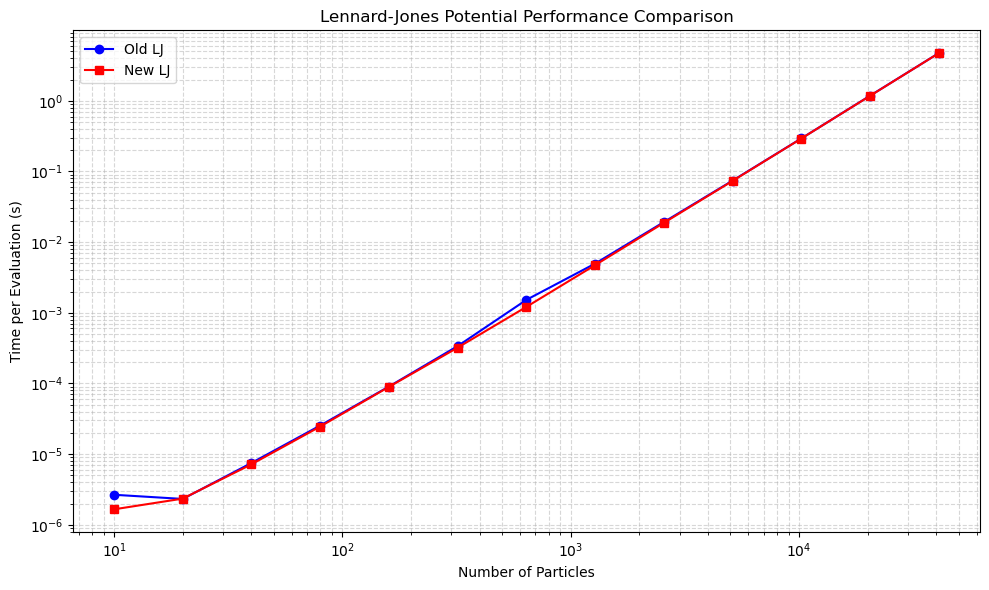

In [4]:
import matplotlib.pyplot as plt

# Extract data from tuples
old_lj_particles, old_lj_times = old_lj_bench
lj_particles, lj_times = lj_bench

# Create the figure and axis
plt.figure(figsize=(10, 6))

# Plot both datasets
plt.plot(old_lj_particles, old_lj_times, 'o-', label='Old LJ', color='blue')
plt.plot(lj_particles, lj_times, 's-', label='New LJ', color='red')

# Set plot to logarithmic scale for better visualization
plt.xscale('log')
plt.yscale('log')

# Add labels and title
plt.xlabel('Number of Particles')
plt.ylabel('Time per Evaluation (s)')
plt.title('Lennard-Jones Potential Performance Comparison')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

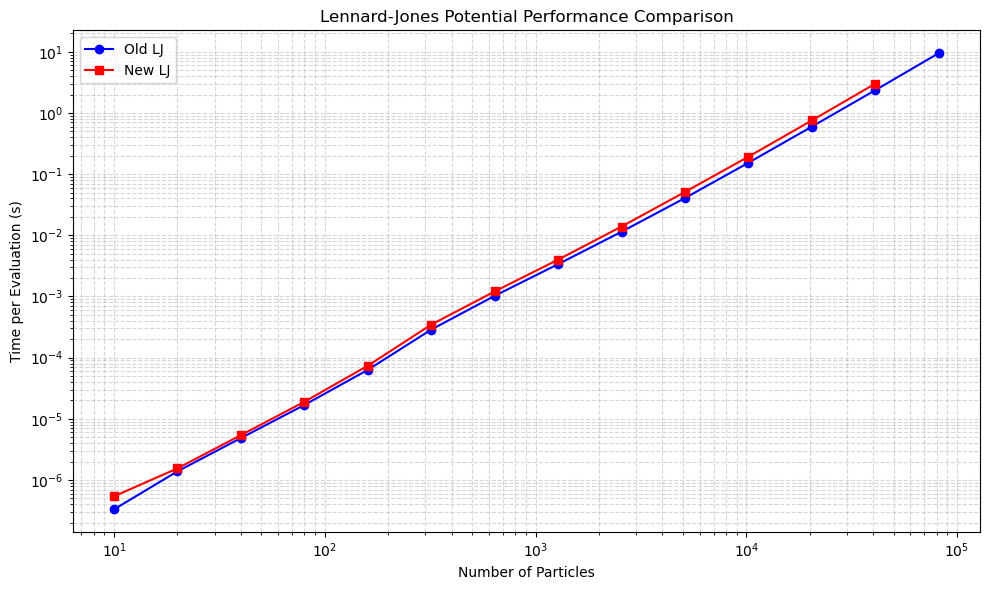

In [5]:
# Extract data from tuples
old_lj_particles, old_lj_times = old_inversepower_bench
lj_particles, lj_times = inversepower_bench

# Create the figure and axis
plt.figure(figsize=(10, 6))

# Plot both datasets
plt.plot(old_lj_particles, old_lj_times, 'o-', label='Old LJ', color='blue')
plt.plot(lj_particles, lj_times, 's-', label='New LJ', color='red')

# Set plot to logarithmic scale for better visualization
plt.xscale('log')
plt.yscale('log')

# Add labels and title
plt.xlabel('Number of Particles')
plt.ylabel('Time per Evaluation (s)')
plt.title('Lennard-Jones Potential Performance Comparison')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

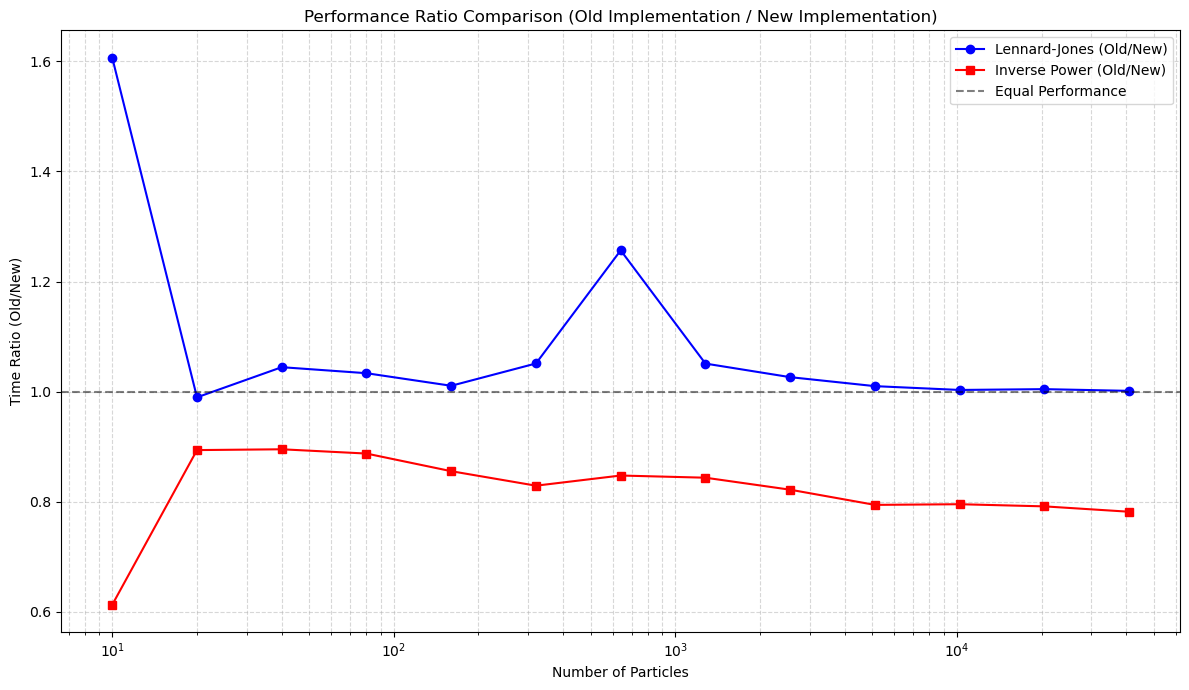

In [8]:
# Extract data from tuples
old_lj_particles, old_lj_times = old_lj_bench
lj_particles, lj_times = lj_bench

old_inverse_particles, old_inverse_times = old_inversepower_bench
inverse_particles, inverse_times = inversepower_bench

# Calculate ratios
lj_ratio = [old / new for old, new in zip(old_lj_times, lj_times)]
inverse_ratio = [old / new for old, new in zip(old_inverse_times[:13], inverse_times)]  # Limiting to same length

# Create the figure and axis
plt.figure(figsize=(12, 7))

# Plot both ratio datasets
plt.plot(lj_particles, lj_ratio, 'o-', label='Lennard-Jones (Old/New)', color='blue')
plt.plot(inverse_particles, inverse_ratio, 's-', label='Inverse Power (Old/New)', color='red')

# Add a horizontal line at y=1 to indicate equal performance
plt.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Equal Performance')

# Set plot to logarithmic scale for x-axis
plt.xscale('log')

# Add labels and title
plt.xlabel('Number of Particles')
plt.ylabel('Time Ratio (Old/New)')
plt.title('Performance Ratio Comparison (Old Implementation / New Implementation)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

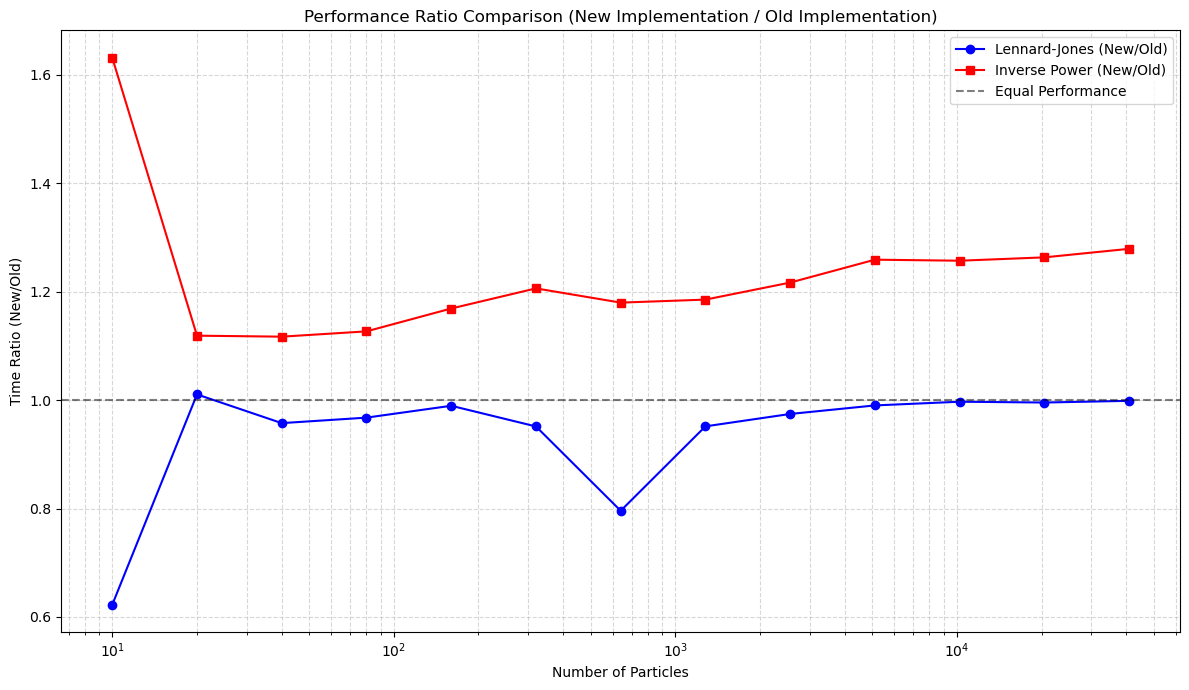

In [7]:
# Calculate ratios
lj_ratio = [new / old for old, new in zip(old_lj_times, lj_times)]
inverse_ratio = [new / old for old, new in zip(old_inverse_times[:13], inverse_times)]  # Limiting to same length

# Create the figure and axis
plt.figure(figsize=(12, 7))

# Plot both ratio datasets with updated labels
plt.plot(lj_particles, lj_ratio, 'o-', label='Lennard-Jones (New/Old)', color='blue')
plt.plot(inverse_particles, inverse_ratio, 's-', label='Inverse Power (New/Old)', color='red')

# Add a horizontal line at y=1 to indicate equal performance
plt.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Equal Performance')

# Set plot to logarithmic scale for x-axis
plt.xscale('log')

# Add labels and title
plt.xlabel('Number of Particles')
plt.ylabel('Time Ratio (New/Old)')
plt.title('Performance Ratio Comparison (New Implementation / Old Implementation)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()